# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer_AFT_DR import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.efficient_kan import *
from models.koopman_operator import Knet
from models.AFT import AttentionFreeTransformer

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.1


In [3]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [4]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'duffing_oscillator'
args.folder = 'simple_duffing_oscillator_AFT_long_term_prediction_dynamic_reencoding'
args.time_steps = 201
args.prediction_length = 50
args.max_time = 10
args.num_samples = 6000
args.bottleneck = 100
args.decoder_loss_weight = .01
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.context_length = 10
args.load_from_checkpoint = True
#args.batch_size = 512


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [5]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [6]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

Generating data...


100%|██████████| 6000/6000 [00:00<00:00, 47885.83it/s]

the shape of the data is torch.Size([6000, 201, 2])
Processing dataset: duffing_oscillator
train_idx: 4800, val_idx: 5400
Processed data shapes - Train: torch.Size([4800, 201, 2]), Val: torch.Size([600, 201, 2]), Test: torch.Size([600, 201, 2])



/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:145: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:146: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:147: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than to

## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [7]:
# Model definition
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

AFT = AttentionFreeTransformer(d_model=args.bottleneck, max_seq_len=args.context_length, device=device)

# Combine AE and Knet as a ModuleDict
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet,'aft_layer': AFT})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [8]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.08M
Total params: 81.30k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): Sequential(
      (0): MLP(
        (net): ModuleList(
          (0): Linear(in_features=2, out_features=100, bias=True)
          (1): LeakyReLU(negative_slope=0.01)
          (2): Linear(in_features=100, out_features=100, bias=True)
          (3): LeakyReLU(negative_slope=0.01)
          (4): Linear(in_features=100, out_features=100, bias=True)
        )
      )
      (1): Dropout(p=0.3, inplace=False)
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=100, out_features=2, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=100, out_features=100, bias=False)
  )
  (aft_

## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [9]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

Model loaded from experiments/simple_duffing_oscillator_AFT_long_term_prediction_dynamic_reencoding/model.pkl


/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_17954/546321609.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_pa


## Training

Train the model using the `Trainer` class with the specified data loaders.

In [10]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

Using the CPU


In [11]:
trainer.train_KoopmanAE()

Training Epochs:   5%|▌         | 5/100 [05:59<1:53:17, 71.55s/it]

Epoch 5/100
Training - Recon Loss: 9.210581e-04, Linear Loss: 2.220491e-05, Pred Loss: 3.405183e-03, Unitary Loss: 7.815137e-07, Total Loss: 7.328247e-05
Validation - Recon Loss: 2.164668e-04, Linear Loss: 1.154717e-05, Pred Loss: 1.418665e-03,Unitary Loss: 5.267465e-07, Total Loss: 2.789850e-05


Training Epochs:  10%|█         | 10/100 [11:56<1:47:01, 71.35s/it]

Epoch 10/100
Training - Recon Loss: 6.521564e-04, Linear Loss: 1.419513e-05, Pred Loss: 1.891157e-03, Unitary Loss: 6.490632e-07, Total Loss: 4.611890e-05
Validation - Recon Loss: 1.268575e-04, Linear Loss: 7.505752e-06, Pred Loss: 2.101939e-03,Unitary Loss: 7.431318e-07, Total Loss: 2.979371e-05


Training Epochs:  15%|█▌        | 15/100 [17:40<1:37:32, 68.85s/it]

...

Training Epochs:  95%|█████████▌| 95/100 [1:50:17<05:38, 67.65s/it]

Epoch 95/100
Training - Recon Loss: 2.603152e-04, Linear Loss: 3.691760e-06, Pred Loss: 6.091172e-04, Unitary Loss: 5.070387e-07, Total Loss: 1.745647e-05
Validation - Recon Loss: 7.267276e-05, Linear Loss: 1.432189e-06, Pred Loss: 1.539661e-04,Unitary Loss: 4.746837e-07, Total Loss: 3.698577e-06


Training Epochs: 100%|██████████| 100/100 [1:56:06<00:00, 69.66s/it]

Epoch 100/100
Training - Recon Loss: 2.979059e-04, Linear Loss: 3.715287e-06, Pred Loss: 7.108669e-04, Unitary Loss: 5.581356e-07, Total Loss: 1.938437e-05
Validation - Recon Loss: 1.683574e-04, Linear Loss: 1.487257e-06, Pred Loss: 2.795082e-04,Unitary Loss: 4.619018e-07, Total Loss: 5.965912e-06


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): Sequential(
       (0): MLP(
         (net): ModuleList(
           (0): Linear(in_features=2, out_features=100, bias=True)
           (1): LeakyReLU(negative_slope=0.01)
           (2): Linear(in_features=100, out_features=100, bias=True)
           (3): LeakyReLU(negative_slope=0.01)
           (4): Linear(in_features=100, out_features=100, bias=True)
         )
       )
       (1): Dropout(p=0.1, inplace=False)
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=100, out_features=100, bias=True)
         (1): LeakyReLU(negative_slope=0.01)
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): LeakyReLU(negative_slope=0.01)
         (4): Linear(in_features=100, out_features=2, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=100, out_features=100, bias=False)
   )
   (aft_layer): AttentionFreeTransformer(
     (Wq): Linear(in_features=100, ou

In [13]:
trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 1.704514e-04, Linear Loss: 1.443879e-06, Pred Loss: 2.721284e-04, Total Loss: 5.869677e-06


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

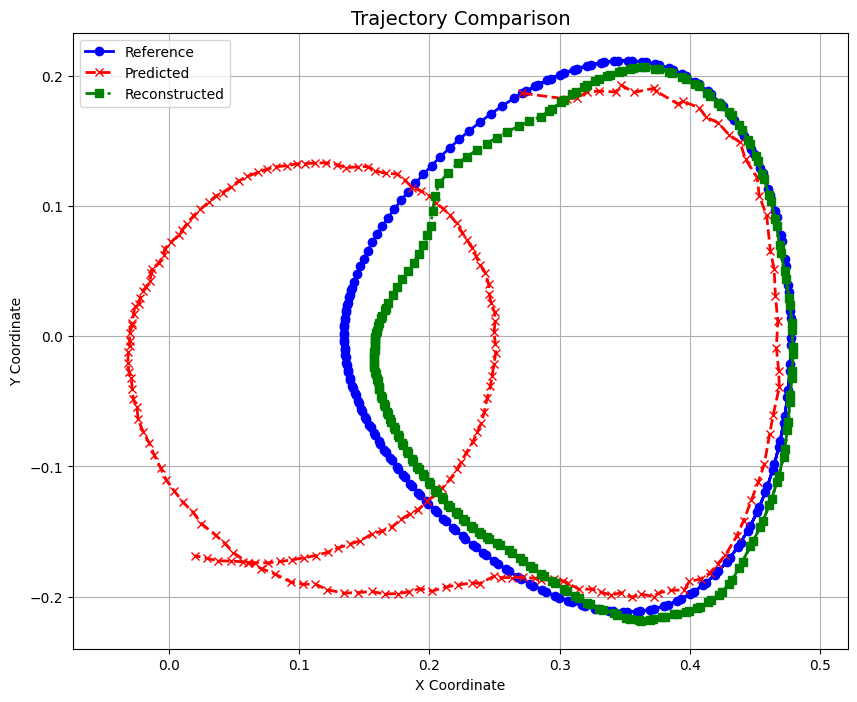

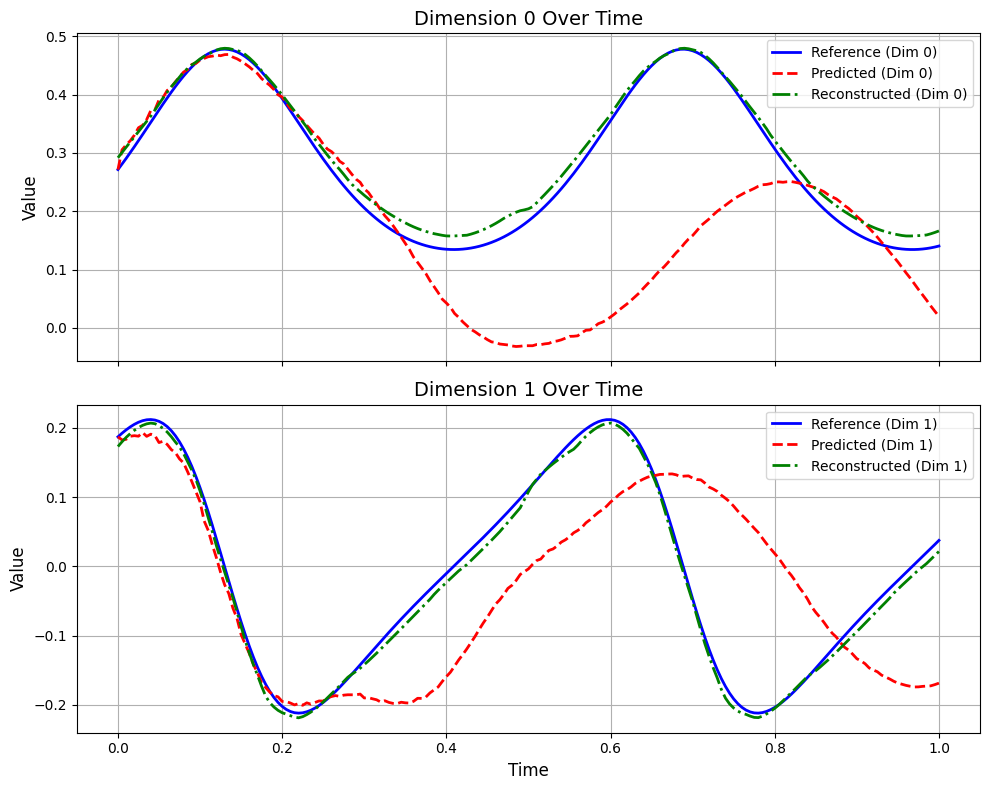

In [12]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][5].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=True)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=True)

## Prediction without Reencoding

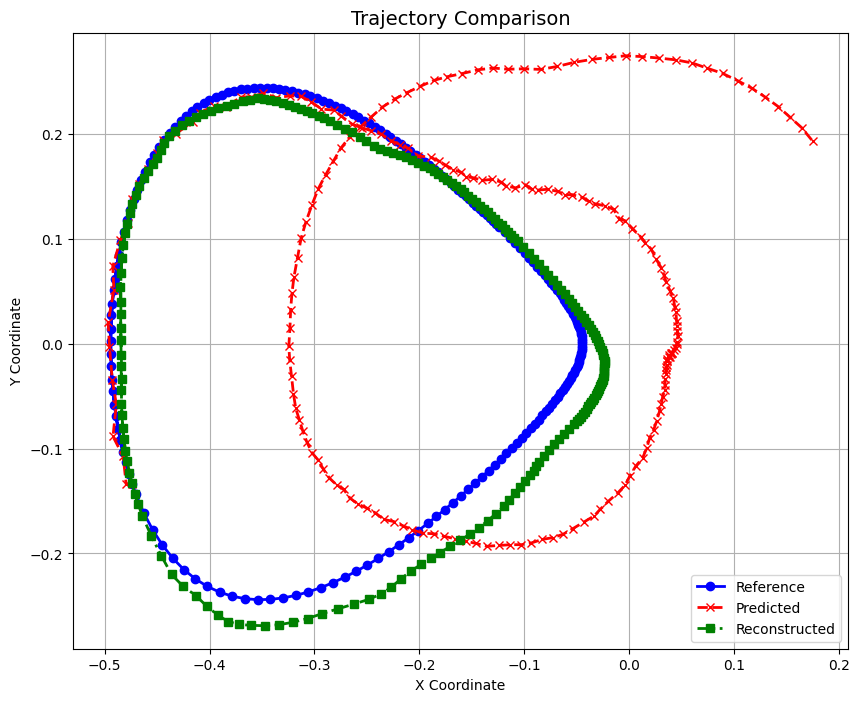

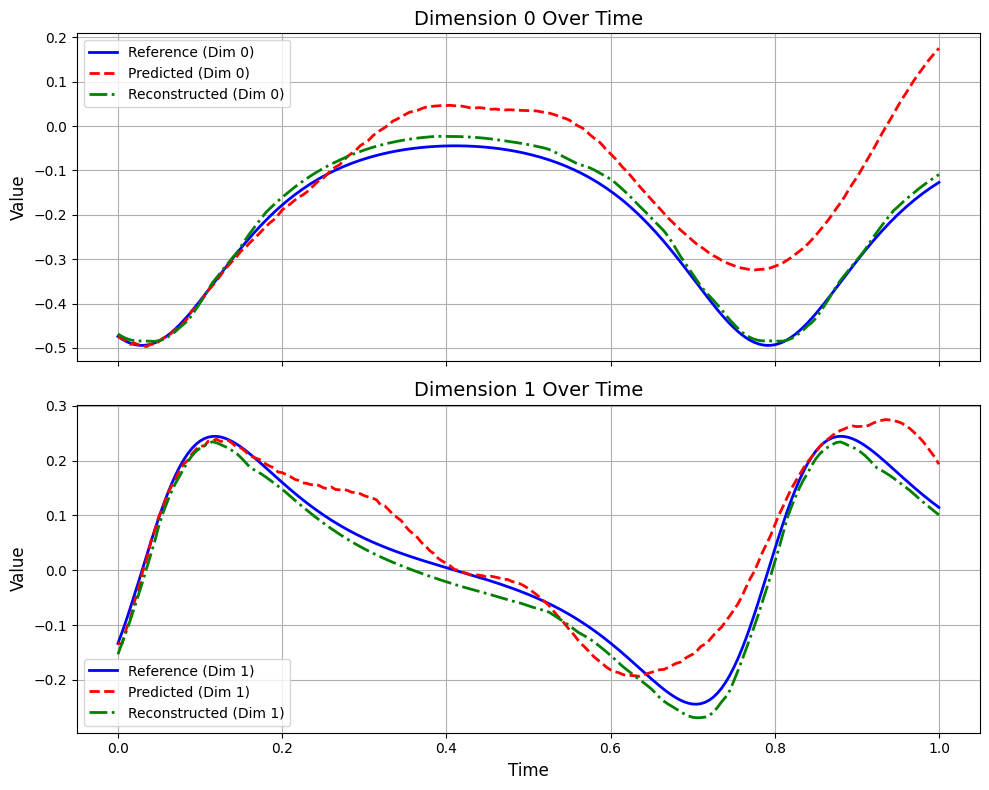

In [104]:
# Get a test sample
traj = preprocessed_data["Xtest"][12].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)


# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Prediction using Periodic Reencoding

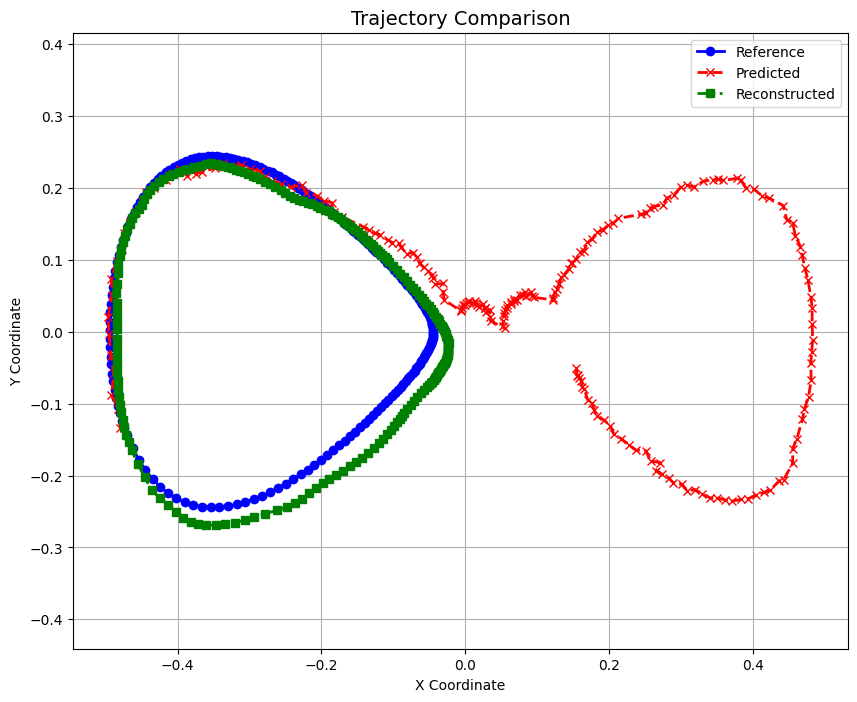

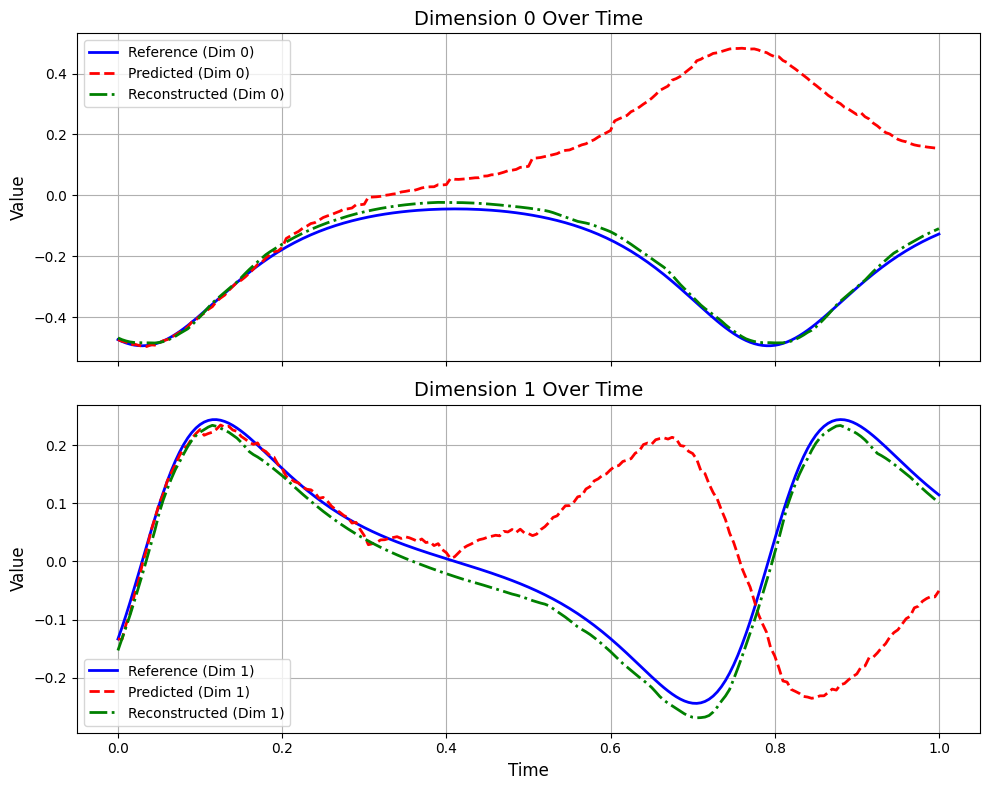

In [103]:
# Get a test sample
traj = preprocessed_data["Xtest"][12].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new_Periodic_Reencoding(X0=traj[0],reenc=20, steps=len(traj)-1)


# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Prediction using encoding on specific points

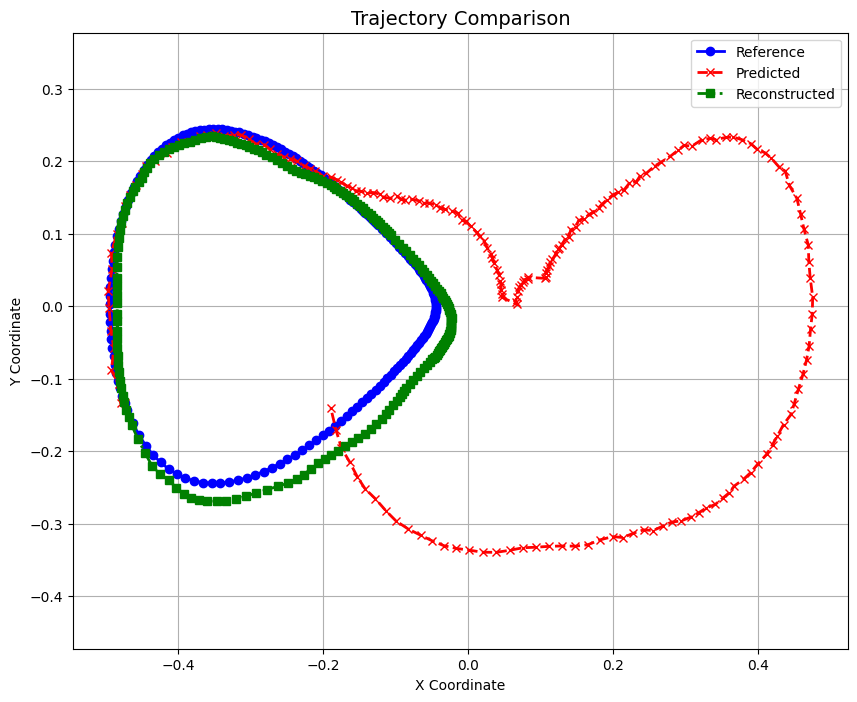

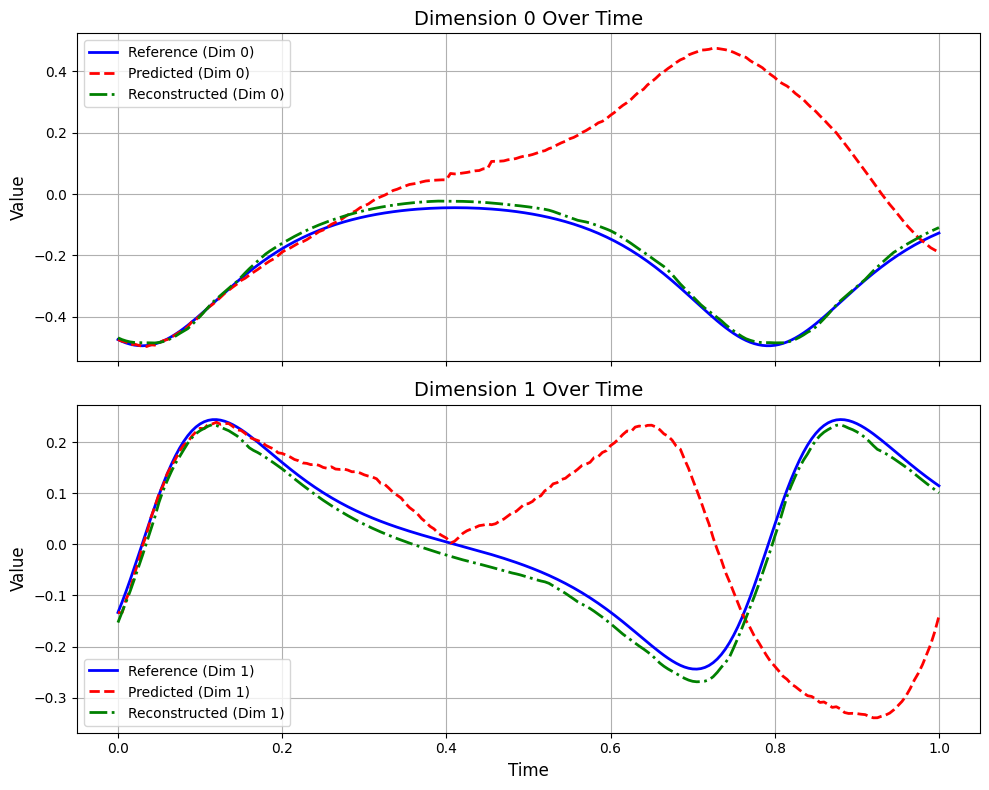

In [102]:
# Get a test sample
traj = preprocessed_data["Xtest"][12].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new_Point_Reencoding(X0=traj[0],reenc=[80,90,200], steps=len(traj)-1)


# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Prediction using specific Threshold

Reencoding points: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 128, 146]


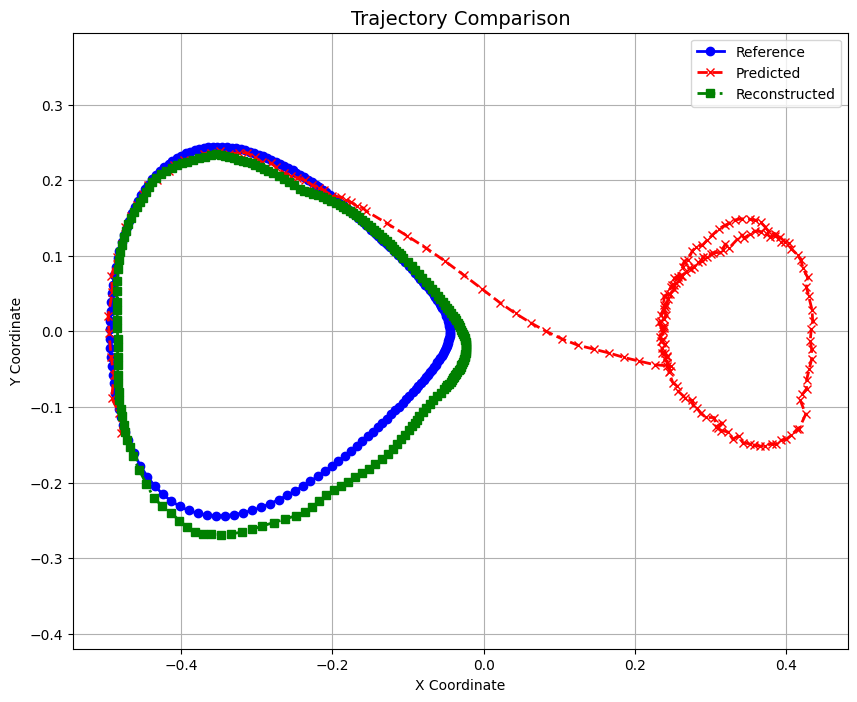

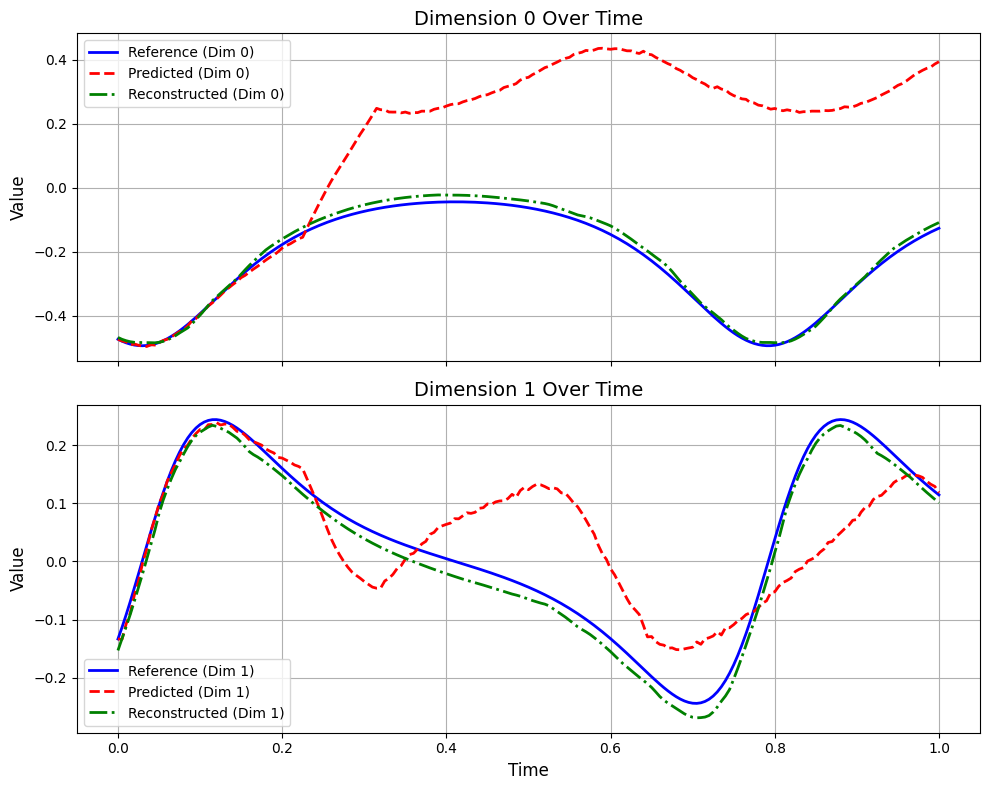

In [101]:
# Get a test sample
traj = preprocessed_data["Xtest"][12].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reenc_points = trainer.predict_with_threshold(X0=traj[0],threshold=0.5, steps=len(traj)-1)


print(f"Reencoding points: {reenc_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Reencoding Using Window Variance

Reencoding points: [29, 31, 33, 43, 53, 63, 73, 83, 85, 87, 89, 105, 112, 114, 147, 166, 168, 170, 172, 174, 184, 194]


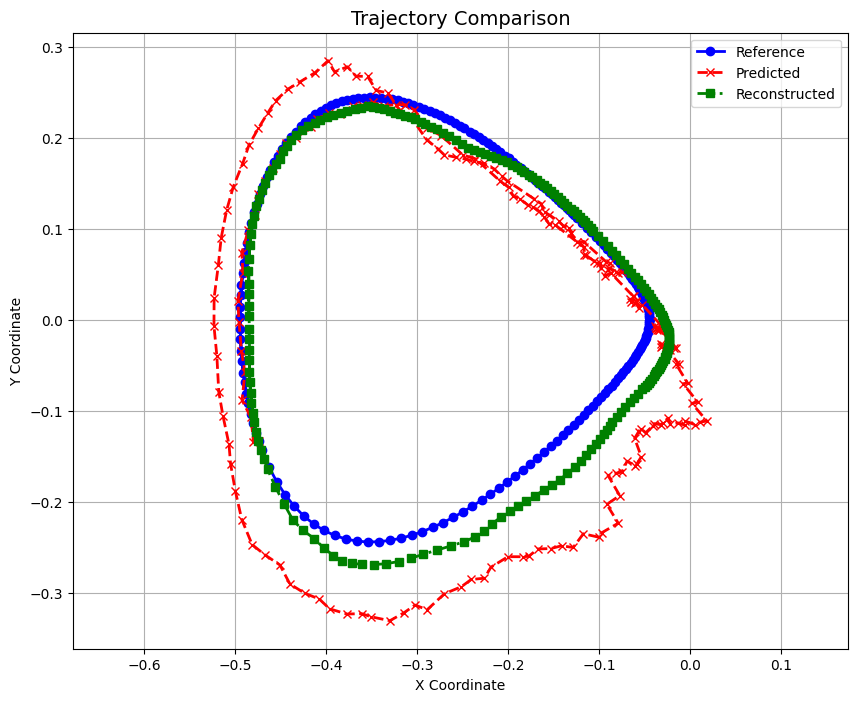

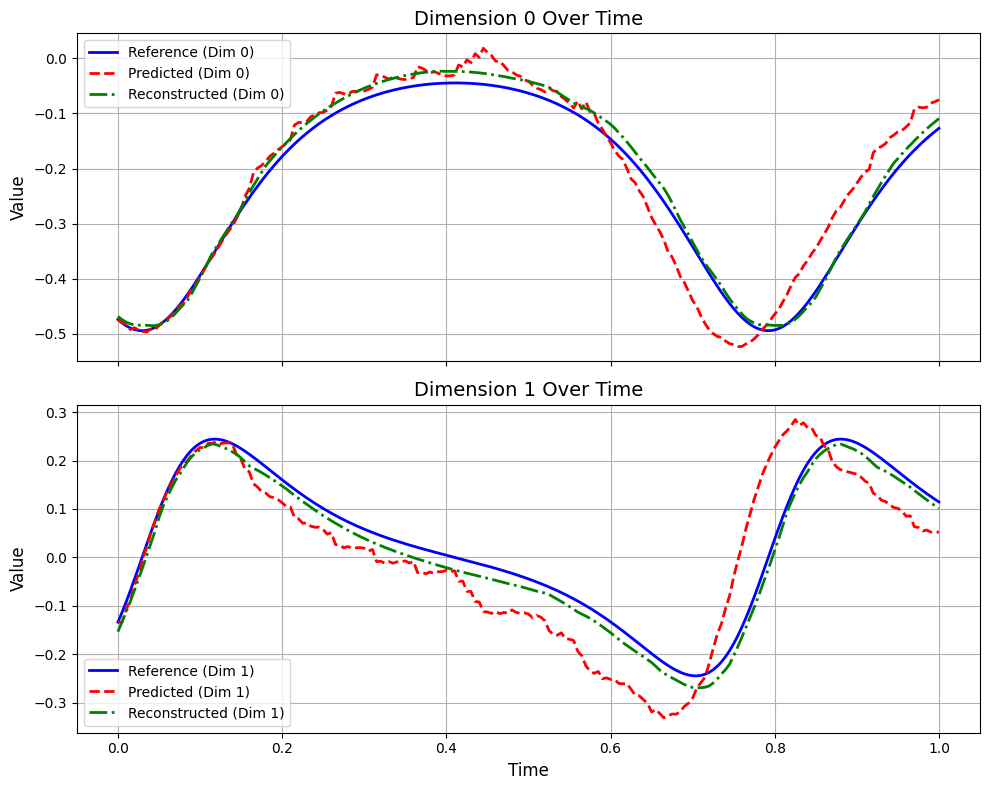

In [96]:
# Get a test sample
traj = preprocessed_data["Xtest"][12].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reenc_points, mse_history = trainer.predict_window_variance(X0=traj[0],window_size=10, variance_threshold=1.5, steps=len(traj)-1)


print(f"Reencoding points: {reenc_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Testing different encoding functions

In [100]:
import torch

def evaluate_all_methods(preprocessed_data, model, trainer, device):
    model.eval()
    Xtest = preprocessed_data["Xtest"]

    # Define the inference methods
    def ae_reconstruction(traj):
        with torch.no_grad():
            _, reconstructed = model.ae(traj)
        return reconstructed

    def predict_new(traj):
        return trainer.predict_new(X0=traj[0], steps=len(traj) - 1)[0]

    def predict_new_periodic(traj):
        return trainer.predict_new_Periodic_Reencoding(X0=traj[0], reenc=20, steps=len(traj) - 1)[0]

    def predict_with_threshold(traj):
        return trainer.predict_with_threshold(X0=traj[0], threshold=0.5, steps=len(traj) - 1)[0]

    def predict_window_variance(traj):
        return trainer.predict_window_variance(X0=traj[0], window_size=10, variance_threshold=2, steps=len(traj) - 1)[0]

    methods = {
        #"ae_reconstruction": ae_reconstruction,
        "predict_new": predict_new,
        "predict_new_periodic": predict_new_periodic,
        "predict_with_threshold": predict_with_threshold,
        "predict_window_variance": predict_window_variance,
    }


    testing_results = {}
    for name, func in methods.items():
        print(f"Evaluating method: {name}")
        result = []
        for traj in Xtest:
            traj = traj.to(device)
            predicted_traj = func(traj)
            mse_diff = torch.mean((predicted_traj - traj) ** 2).item()
            result.append(mse_diff)
        testing_results[name] = np.mean(result)


    return testing_results


# Evaluate all methods
results = evaluate_all_methods(preprocessed_data, model, trainer, device)

print("Evaluation Results:")
for method, mse in results.items():
    print(f"{method}: MSE = {mse:.4f}")


Evaluating method: predict_new
Evaluating method: predict_new_periodic
Evaluating method: predict_with_threshold
Evaluating method: predict_window_variance
Evaluation Results:
predict_new: MSE = 0.0427
predict_new_periodic: MSE = 0.0156
predict_with_threshold: MSE = 0.0290
predict_window_variance: MSE = 0.0186


In [71]:
def test_prediction_function(trainer, preprocessed_data, prediction_func, func_kwargs=None, 
                            device=None, test_subset=None):
    """
    Simple testing function for any prediction method.
    
    Args:
        trainer: The trained model trainer
        preprocessed_data: Dictionary containing test data
        prediction_func: Function to test (should return at least predicted_trajectory)
        func_kwargs: Dictionary of keyword arguments to pass to prediction_func
        device: Device to run computations on
        test_subset: List of indices to test (if None, tests all trajectories)
    
    Returns:
        dict: Dictionary containing MSE statistics and results
    """
    if device is None:
        device = trainer.device
    
    if func_kwargs is None:
        func_kwargs = {}
    
    test_data = preprocessed_data["Xtest"]
    
    # Determine which trajectories to test
    if test_subset is None:
        test_indices = range(len(test_data))
    else:
        test_indices = test_subset
    
    print(f"Testing {len(test_indices)} trajectories with {prediction_func.__name__}")
    print(f"Arguments: {func_kwargs}")
    print("-" * 60)
    
    mse_errors = []
    results = []
    
    for i in test_indices:
        traj = test_data[i].to(device)
        X0 = traj[0]
        steps = len(traj) - 1
        
        try:
            # Call prediction function
            pred_result = prediction_func(X0=X0, steps=steps, **func_kwargs)
            
            # Extract predicted trajectory (first return value)
            if isinstance(pred_result, tuple):
                predicted_traj = pred_result[0]
                extra_info = pred_result[1:] if len(pred_result) > 1 else ()
            else:
                predicted_traj = pred_result
                extra_info = ()
            
            # Calculate MSE
            mse_error = torch.mean((traj - predicted_traj) ** 2).item()
            mse_errors.append(mse_error)
            
            # Store result
            result = {
                'idx': i,
                'mse': mse_error,
                'length': len(traj)
            }
            
            # Add reencoding info if available
            if len(extra_info) > 0:
                try:
                    # Check if second return value looks like reencoding points
                    if hasattr(extra_info[0], '__len__') and not isinstance(extra_info[0], torch.Tensor):
                        reenc_points = list(extra_info[0]) if extra_info[0] is not None else []
                        result['reenc_points'] = reenc_points
                        result['reenc_count'] = len(reenc_points)
                except:
                    pass
            
            results.append(result)
            
            # Print individual result
            output = f"Traj {i:3d}: MSE = {mse_error:.6f}"
            if 'reenc_count' in result:
                output += f", Reencodings = {result['reenc_count']:2d}"
                if result['reenc_count'] > 0:
                    output += f" at {result['reenc_points']}"
            print(output)
            
        except Exception as e:
            print(f"Error with trajectory {i}: {e}")
            continue
    
    # Calculate statistics
    if not mse_errors:
        print("No successful predictions!")
        return None
    
    mse_tensor = torch.tensor(mse_errors)
    
    stats = {
        'num_tested': len(mse_errors),
        'mean_mse': mse_tensor.mean().item(),
        'std_mse': mse_tensor.std().item(),
        'min_mse': mse_tensor.min().item(),
        'max_mse': mse_tensor.max().item(),
        'results': results
    }
    
    # Add reencoding stats if applicable
    reenc_counts = [r.get('reenc_count', 0) for r in results if 'reenc_count' in r]
    if reenc_counts:
        stats['total_reencodings'] = sum(reenc_counts)
        stats['avg_reencodings'] = sum(reenc_counts) / len(reenc_counts)
        stats['trajectories_with_reenc'] = sum(1 for c in reenc_counts if c > 0)
    
    # Print summary
    print("-" * 60)
    print(f"SUMMARY:")
    print(f"Tested: {stats['num_tested']} trajectories")
    print(f"Mean MSE: {stats['mean_mse']:.6f} ± {stats['std_mse']:.6f}")
    print(f"Min MSE:  {stats['min_mse']:.6f}")
    print(f"Max MSE:  {stats['max_mse']:.6f}")
    
    if 'total_reencodings' in stats:
        print(f"Total reencodings: {stats['total_reencodings']}")
        print(f"Avg reencodings per trajectory: {stats['avg_reencodings']:.1f}")
        print(f"Trajectories with reencoding: {stats['trajectories_with_reenc']}/{stats['num_tested']}")
    
    return stats


In [ ]:
# Usage examples:

# Test all trajectories with threshold-based reencoding
all_results = test_prediction_function(
    trainer, preprocessed_data,
    trainer.predict_with_threshold,
    {'threshold': 0.5}
)

all_results_window = test_prediction_function(
    trainer, preprocessed_data,
    trainer.predict_window_variance,
    {'window_size': 10, 'variance_threshold': 2.0}
)

all_results_no_reenc = test_prediction_function(
    trainer, preprocessed_data,
    trainer.predict_new,
    {'reenc': 200}
)

# Test first 10 trajectories with no reencoding
subset_results = test_prediction_function(
    trainer, preprocessed_data,
    trainer.predict_new,
    {'reenc_points': None},
    test_subset=range(10)
)

# Test specific trajectory (like trajectory 32)
single_result = test_prediction_function(
    trainer, preprocessed_data,
    trainer.predict_with_threshold,
    {'threshold': 0.5},
    test_subset=[32]
)

Testing 600 trajectories with predict_with_threshold
Arguments: {'threshold': 0.5}
------------------------------------------------------------
Traj   0: MSE = 0.001650
Traj   1: MSE = 0.007137
Traj   2: MSE = 0.000871
Traj   3: MSE = 0.028136
Traj   4: MSE = 0.037649
Traj   5: MSE = 0.001258
Traj   6: MSE = 0.028824
Traj   7: MSE = 0.005578
Traj   8: MSE = 0.078524
Traj   9: MSE = 0.000900
Traj  10: MSE = 0.008710
Traj  11: MSE = 0.002645
Traj  12: MSE = 0.104501
Traj  13: MSE = 0.088895
Traj  14: MSE = 0.008584
Traj  15: MSE = 0.015296
Traj  16: MSE = 0.059669
Traj  17: MSE = 0.010924
Traj  18: MSE = 0.001626
Traj  19: MSE = 0.061865
Traj  20: MSE = 0.000869
Traj  21: MSE = 0.023175
Traj  22: MSE = 0.046464
Traj  23: MSE = 0.000865
Traj  24: MSE = 0.030114
Traj  25: MSE = 0.004070
Traj  26: MSE = 0.006190
Traj  27: MSE = 0.004712
Traj  28: MSE = 0.033507
Traj  29: MSE = 0.038176
Traj  30: MSE = 0.000672
Traj  31: MSE = 0.026659
Traj  32: MSE = 0.015344
Traj  33: MSE = 0.002845
Traj  

/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_84455/2644213099.py:101: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1823.)
  'std_mse': mse_tensor.std().item(),


## Testing on Test Loader

In [16]:
# print length of test_loader
print(f" the length of the test_loader is {len(test_loader.dataset)}")

 the length of the test_loader is 12000


In [17]:
print(test_loader.dataset[0][0].shape)

torch.Size([11, 2])


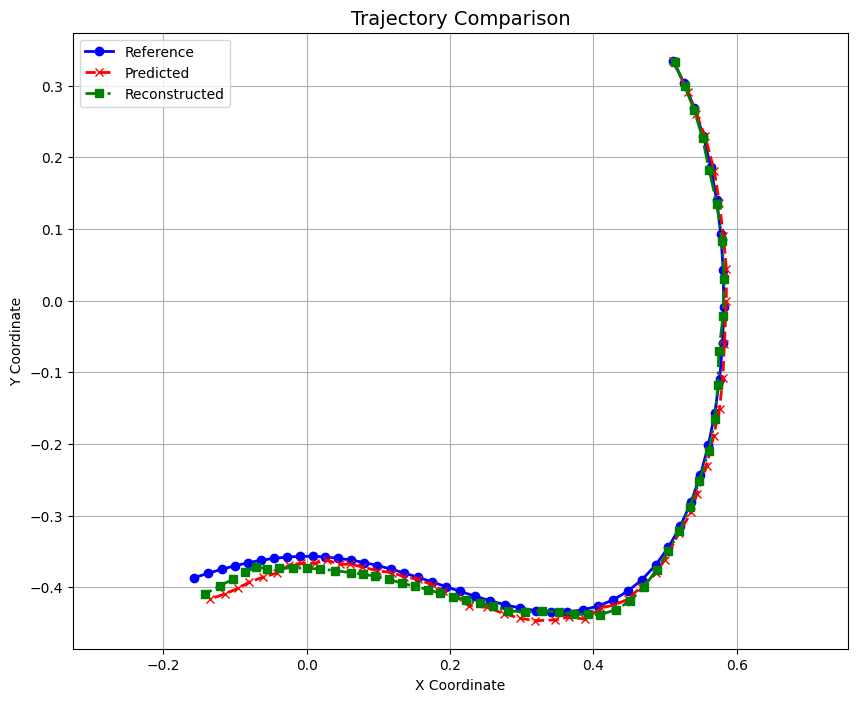

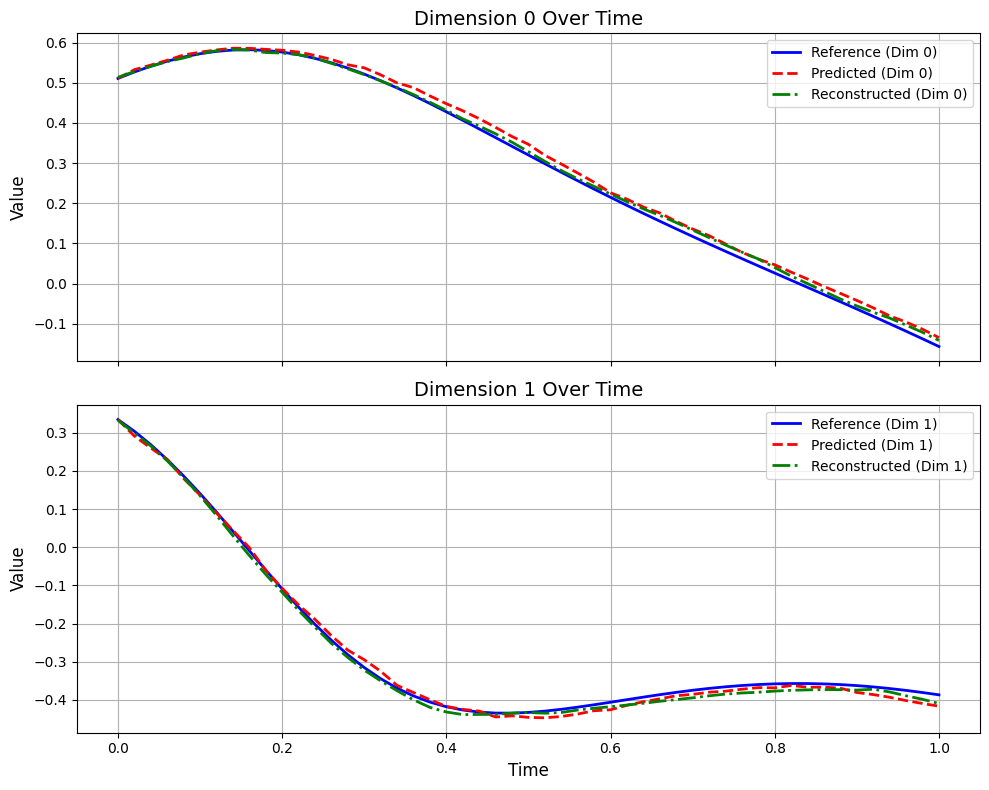

In [41]:
# Get a test sample
traj = train_loader.dataset[6000][0].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 1.0002465 -0.00574841j  1.0002465 +0.00574841j  0.9981804 +0.05531489j
  0.9981804 -0.05531489j  0.99584436+0.08925145j  0.99584436-0.08925145j
  0.9876975 -0.15580207j  0.9876975 +0.15580207j  0.98013127+0.19781522j
  0.98013127-0.19781522j  0.96541244+0.2608361j   0.96541244-0.2608361j
  0.9107083 +0.41304642j  0.9107083 -0.41304642j  0.8763931 +0.48159993j
  0.8763931 -0.48159993j  0.8450225 -0.53478855j  0.8450225 +0.53478855j
  0.8300705 +0.55759555j  0.8300705 -0.55759555j  0.7913257 +0.61139274j
  0.7913257 -0.61139274j  0.7255596 +0.6881595j   0.7255596 -0.6881595j
  0.6845275 -0.7290194j   0.6845275 +0.7290194j   0.63434803+0.7729651j
  0.63434803-0.7729651j   0.6164727 -0.78743535j  0.6164727 +0.78743535j
  0.5513208 -0.83432305j  0.5513208 +0.83432305j  0.5129807 -0.85833406j
  0.5129807 +0.85833406j  0.4440059 -0.8960251j   0.4440059 +0.8960251j
  0.34165975-0.9398363j   0.34165975+0.9398363j   0.310809  -0.95046294j
  0.310809  +0.95046294j  0.24000376+0.970

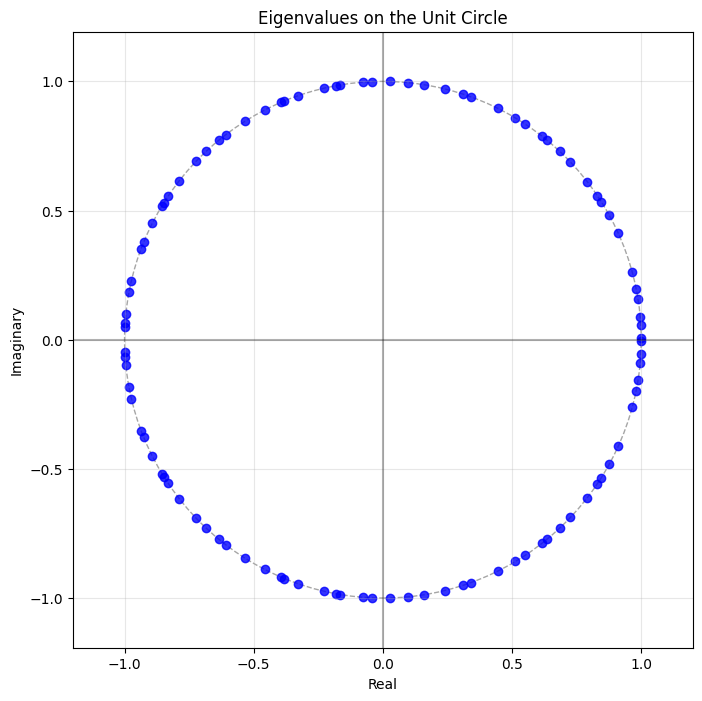

In [42]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

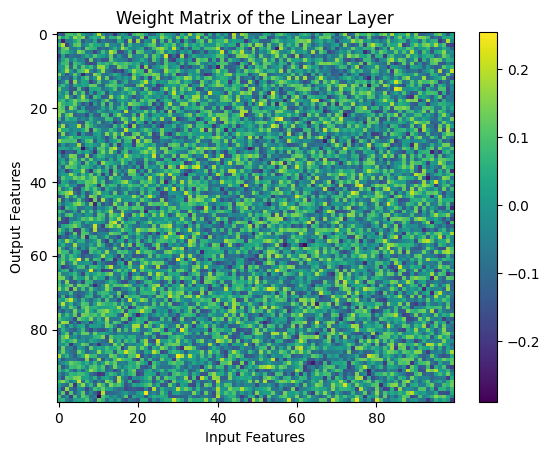

In [43]:
# print the knet weights
weights = model.knet.net.weight.cpu().detach().numpy() 
# Visualize the weight matrix using matplotlib
plt.imshow(weights, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title("Weight Matrix of the Linear Layer")
plt.xlabel("Input Features")
plt.ylabel("Output Features")
plt.show()


In [44]:
# print the entire koopman operator in full 
print(f" the koopman operator is {model.knet.net.weight[0]}")

 the koopman operator is tensor([-0.1168, -0.1529,  0.0973,  0.0977,  0.0628,  0.1417,  0.0157, -0.0501,
        -0.0835,  0.0282,  0.2039, -0.0184, -0.1214, -0.0624, -0.2137, -0.0662,
         0.0209, -0.0395, -0.1725,  0.0770,  0.1243,  0.1007,  0.0091, -0.1200,
        -0.0988,  0.0086,  0.1099,  0.0126,  0.0006, -0.0414, -0.1358,  0.0646,
        -0.0374,  0.1778, -0.0132,  0.1205,  0.0930, -0.1447,  0.0463, -0.1202,
         0.0475, -0.0731,  0.0184, -0.1621,  0.1944, -0.0987,  0.1695,  0.1215,
        -0.0599, -0.0866, -0.0749, -0.0893,  0.0517,  0.0129, -0.1113,  0.0726,
         0.1114,  0.0437, -0.0230, -0.0631, -0.0891,  0.0406,  0.0824,  0.0327,
        -0.1155,  0.0556, -0.0877,  0.0938,  0.0910,  0.0214, -0.1615,  0.0219,
         0.1728, -0.1274, -0.0806,  0.1401,  0.0680,  0.0709,  0.1350,  0.0589,
        -0.0325,  0.1039,  0.1507,  0.0111,  0.1814,  0.0091,  0.0644,  0.0458,
         0.1466, -0.0541,  0.1440, -0.1203, -0.1137, -0.0792, -0.0540,  0.0939,
         0.1298

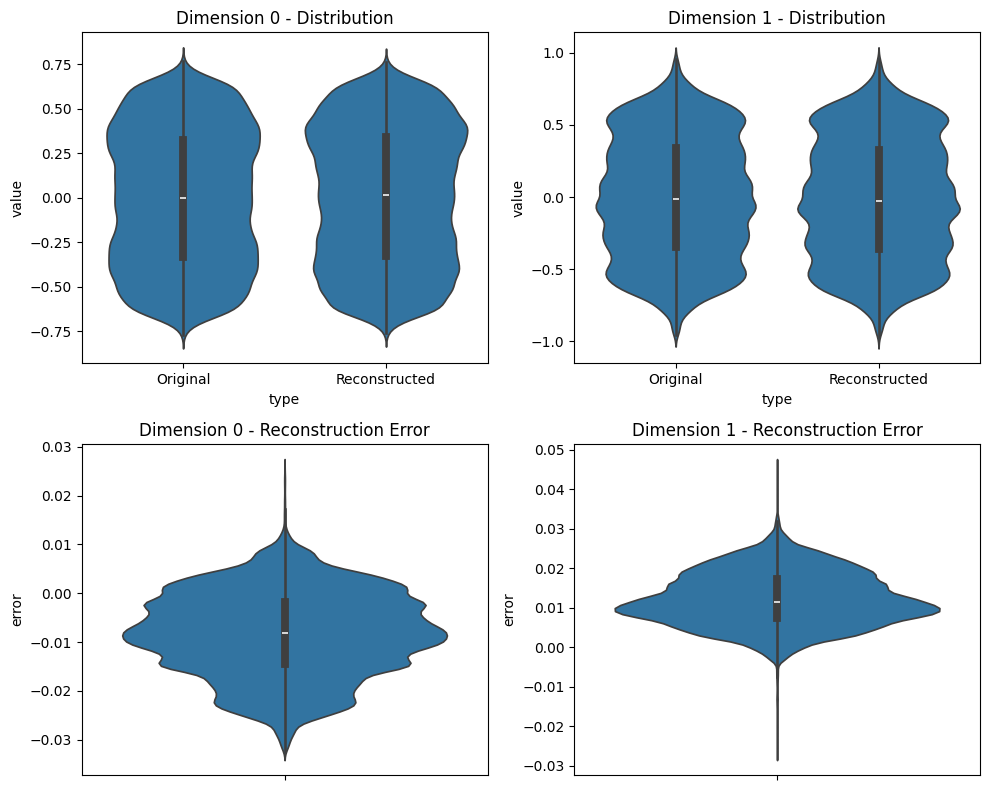

In [45]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)